In [ ]:
import pandas as pd

df = pd.read_csv("evn_peak_MW.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# weekly mean
weekly = df.resample('W-MON', on='date').mean()

weekly.head()


,peak_MW
date,
2023-07-10,42064.985714
2023-07-17,42194.385714
2023-07-24,37753.600000
2023-07-31,40488.885714
2023-08-07,38012.585714


In [2]:
train = weekly.iloc[:-8]   # 8 tuần cuối làm test
test  = weekly.iloc[-8:]


In [3]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(train['peak_MW'],
                order=(1,1,1),
                seasonal_order=(1,1,1,52))   # season 1 năm (52 tuần)

result = model.fit()


C:\Users\Nam Khanh\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [4]:
forecast = result.get_forecast(steps=len(test))
pred = forecast.predicted_mean


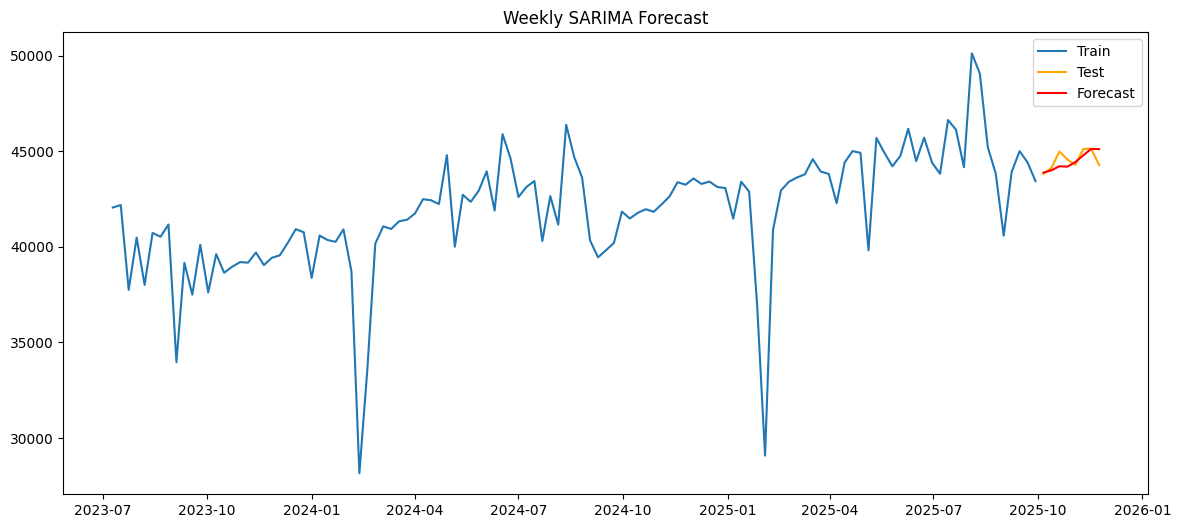

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(train.index, train['peak_MW'], label='Train')
plt.plot(test.index, test['peak_MW'], label='Test', color='orange')
plt.plot(pred.index, pred.values, label='Forecast', color='red')
plt.title("Weekly SARIMA Forecast")
plt.legend()
plt.show()


In [6]:
import numpy as np

mae = np.mean(np.abs(test['peak_MW'] - pred))
rmse = np.sqrt(np.mean((test['peak_MW'] - pred)**2))
mape = np.mean(np.abs((test['peak_MW'] - pred) / test['peak_MW'])) * 100

mae, rmse, mape


(np.float64(333.7115892603515),
 np.float64(446.1032211589474),
 np.float64(0.7478490942057532))